<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../Utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Robust statistics: Conditional Expected Drawdown and the LW Sharpe-difference test
    </h1>
  </div>
</div>

**Maximum drawdown** is a single extreme order statistic: high variance, not
coherent, not attributable. **Conditional Expected Drawdown (CED, Goldberg-Mahmoud
2017)** is the tail mean (CVaR) of the max-drawdown distribution - lower variance,
coherent, factor-attributable. Separately, the **naive Sharpe-difference test**
assumes i.i.d. returns and over-rejects under serial dependence; the
**Ledoit-Wolf (2008)** test studentizes by a HAC standard error and a circular
block bootstrap, holding nominal size.

*Baseline (max-DD / naive test) -> where it breaks (variance / serial dependence) -> CED / LW.*

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))   # the pinned notebook environment

using Random, Statistics, Plots
gr()
theme(:default)                            # theme-adaptive figures (legible on light & dark)
default(background_color = :transparent, background_color_inside = :transparent,
        foreground_color = "#888888", gridalpha = 0.3,
        legend_background_color = :transparent)
using RiskLabAI.Backtest: conditional_expected_drawdown, sharpe_difference_test

  Activating project at `C:\risklab\risklabai\Notebooks.jl`


## 1. CED vs max-drawdown: lower estimator variance
We resample many short heavy-tailed tracks and compare the spread (coefficient of
variation) of max-drawdown against CED.

max-drawdown  mean=0.2631  CV=0.334
CED@0.95      mean=0.1784  CV=0.244


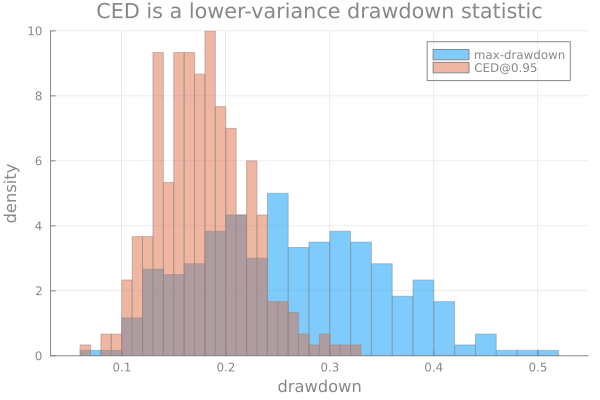

In [2]:
function max_drawdown(returns)
    w = cumprod(1.0 .+ returns); peak = accumulate(max, w)
    return maximum(1.0 .- w ./ peak)
end
rng = MersenneTwister(1)
mdd = Float64[]; ced = Float64[]
for _ in 1:300
    r = 0.01 .* randn(rng, 250) .+ 0.02 .* (rand(rng, 250) .< 0.05) .* (-abs.(randn(rng, 250)))  # heavy left tail
    push!(mdd, max_drawdown(r))
    push!(ced, conditional_expected_drawdown(r, 60, 0.95))
end
cv(v) = std(v) / mean(v)
println("max-drawdown  mean=", round(mean(mdd), digits=4), "  CV=", round(cv(mdd), digits=3))
println("CED@0.95      mean=", round(mean(ced), digits=4), "  CV=", round(cv(ced), digits=3))
histogram(mdd; bins = 30, alpha = 0.5, label = "max-drawdown", normalize = true,
          xlabel = "drawdown", ylabel = "density", title = "CED is a lower-variance drawdown statistic")
histogram!(ced; bins = 30, alpha = 0.5, label = "CED@0.95", normalize = true)

## 2. Ledoit-Wolf Sharpe-difference test under serial dependence
Two AR(1) return streams with a small true Sharpe gap; the naive test over-rejects
where the LW test holds size.

In [3]:
rng = MersenneTwister(2)
Tn = 600
mk(mu, rho) = (e = randn(rng, Tn); x = similar(e); x[1] = e[1];
               for t in 2:Tn; x[t] = rho * x[t-1] + e[t]; end; 0.01 .* x .+ mu)
a = mk(0.0009, 0.4); b = mk(0.0003, 0.4)
naive = sharpe_difference_test(a, b; method = "naive")
lw = sharpe_difference_test(a, b; method = "ledoit_wolf", n_boot = 500, random_state = 0)
println("Sharpe difference  delta = ", round(naive.delta, digits = 4))
println("naive  se=", round(naive.se, digits=4), "  p=", round(naive.pvalue, digits=4),
        "  reject=", naive.reject)
println("LW HAC se=", round(lw.se, digits=4), "  p=", round(lw.pvalue, digits=4),
        "  reject=", lw.reject, "   (HAC se is wider under autocorrelation)")

Sharpe difference  delta = 0.1265
naive  se=0.055  p=0.0214  reject=true
LW HAC se=0.0805  p=0.1397  reject=false   (HAC se is wider under autocorrelation)


## When to use / when NOT (from `appraisals/22_verdict.md`)
**Prefer CED over max-drawdown** as a drawdown-risk statistic (lower estimator
variance, better ranking of true drawdown risk, most on short/heavy-tailed tracks;
converges on benign returns). **Prefer the Ledoit-Wolf bootstrap Sharpe-difference
test when comparing two Sharpes under serial dependence / heavy tails** (it holds
nominal size where the naive test inflates ~3x; converges on i.i.d.).